Importando as bibliotecas e módulos necessários: 

In [1]:
import os
import pandas as pd
import numpy as np
import sys
import gc

Importando as bases necessárias: 

In [2]:
df_final = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\BASE_UNIF.parquet", engine="pyarrow")

In [3]:
df_final_2 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\BASE_AED.parquet", engine="pyarrow")

Nessa etapa será feita a definição das variáveis a serem utilizadas:

• Dependente: nível de proficiência em matemática, categorizado;

• Independentes: a definir a partir da análise exploratória e de métricas de importância.
Serão explorados diferentes métodos para realizar essa seleção.

### 1. Categorização do nível de proficiência
Esta seção descreve o processo de categorização inicial a ser adotado: a classificação em 4 classes de proficiência (QEdu), e a divisão em 10 níveis (INEP), sendo eles:

• Insuficiente, para proficiências entre 0-224, Níveis 0 e 1

• Básico, para proficiências entre 225-299, Níveis 2, 3 e 4

• Proficiente, para proficiências entre 300-349, Níveis 5 e 6 

• Avançado, para proficiências a partir de 350, Níveis 7, 8 e 9

In [4]:
bins = [-float('inf'), 200, 225, 250, 275, 300, 325, 350, 375, 400, float('inf')]
labels_numericos = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
labels_proficiencia = [
    'Insuficiente', 
    'Básico',       
    'Proficiente',   
    'Avançado'     
]

In [5]:
#REGIAO, AREA, PUBLICA, LOCALIZACAO, IN_PROFICIENCIA_MT, PROFICIENCIA_MT_SAEB, SEXO, IDADE, COR/RACA, NECESSIDADE ESPECIAL, ESCOLARIDADE MÃE, ESCOLARIDADE PAI, FREQUENCIA LEITURA, FREQUENCIA CONVERSA, FREQUENCIA INCENTIVO ESTUDO, FREQUENCIA INCENIVO TAREFA, FREQUENCIA INCENTIVO AULAS, FREQUENCIA REUNIOES, ASFALTO/CALCAMENTO, AGUA TRATADA, ILUMINAÇAO, TEMPO ATE ESCOLA, LOCOMOCAO ATE ESCOLA, TRANSPORTE OU PASSE, IDADE INTROD ESCOLAR, TIPO ESCOLA, REPROVAÇAO, ABANDONO, TEMPO ESTUDO, TEMPO CURSOS,TEMPO TRAB DOMESTICO, TEMPO TRABALHO FORA, TEMPO LAZER.

### 2. Seleção de características baseada na Análise Exploratória

#### 2019
Colunas selecionadas: LOCALIZACAO, COR/RACA, ESCOL_MAE, FREQUENCIA_CONVERSA, QTD_COMPUTADOR, QTD_CARRO, GARAGEM, IDADE_INTROD_ESC, REPROVACAO, TEMPO_ESTUDO, TEMPO_TRAB_DOMES, POS_EF

In [6]:
df_2019 = df_final[df_final["ANO"] == 2019]

df_2019['NIVEL_PROFICIENCIA'] = pd.cut(df_2019['PROFICIENCIA_SAEB'], bins=bins, labels=labels_numericos, right=False)

nivel_to_proficiencia = {0: 'Insuficiente', 1: 'Insuficiente', 2: 'Básico', 3: 'Básico', 4: 'Básico',
                         5: 'Proficiente', 6: 'Proficiente', 7: 'Avançado', 8: 'Avançado', 9: 'Avançado'}

df_2019['PROFICIENCIA_DESCRICAO'] = df_2019['NIVEL_PROFICIENCIA'].map(nivel_to_proficiencia)

colunas = [
    'LOCALIZACAO', 'COR_RACA', 'ESCOL_MAE', 'FREQUENCIA_CONVERSA', 'QTD_COMPUTADOR', 'QTD_CARRO', 'GARAGEM', 'IDADE_INTROD_ESC',     
    'REPROVACAO', 'TEMPO_ESTUDO', 'TEMPO_TRAB_DOMES', 'POS_EF', 'PROFICIENCIA_DESCRICAO'

]

df_2019 = df_2019[colunas]
df_2019.head()

,LOCALIZACAO,COR_RACA,ESCOL_MAE,FREQUENCIA_CONVERSA,QTD_COMPUTADOR,QTD_CARRO,GARAGEM,IDADE_INTROD_ESC,REPROVACAO,TEMPO_ESTUDO,TEMPO_TRAB_DOMES,POS_EF,PROFICIENCIA_DESCRICAO
0,1,Branca,Fundamental incompleto,Às vezes,Não respondeu,1 ou 2,Sim,Entre 4 e 7,Sim,Menos de 1 hora,Mais de 2 horas,Estudar e trabalhar,Básico
1,1,Parda,Superior completo,Sempre,0,1 ou 2,Sim,Entre 4 e 7,Não,Menos de 1 hora,Mais de 2 horas,Estudar e trabalhar,Básico
2,1,Parda,Não sabe,Às vezes,0,0,Não,Entre 4 e 7,Não,Entre 1 e 2 horas,Mais de 2 horas,Não sabe,Básico
3,1,Parda,Superior completo,Às vezes,1 ou 2,1 ou 2,Sim,Entre 4 e 7,Não,Entre 1 e 2 horas,Mais de 2 horas,Não sabe,Básico
4,1,Branca,Fundamental incompleto,Nunca,0,1 ou 2,Sim,Entre 4 e 7,Não,Menos de 1 hora,Não respondeu,Estudar e trabalhar,Básico


In [7]:
# Verificando a distribuição das classes 
class_distribution = df_2019['PROFICIENCIA_DESCRICAO'].value_counts()

# Total de registros no dataframe
total_records = len(df_2019)

print("Distribuição de registros:")
for classe, quantidade in class_distribution.items():
    porcentagem = (quantidade / total_records) * 100
    print(f"Classe {classe}: {quantidade} registros ({porcentagem:.2f}%)")

# Verificando se a soma total bate
print(f"\nSoma total de registros: {class_distribution.sum()} (Esperado: {total_records})")


Distribuição de registros:
Classe Básico: 1042352 registros (54.52%)
Classe Insuficiente: 507526 registros (26.55%)
Classe Proficiente: 315123 registros (16.48%)
Classe Avançado: 46930 registros (2.45%)

Soma total de registros: 1911931 (Esperado: 1911931)


#### 2021
Colunas selecionadas: LOCALIZACAO, SEXO, COR/RACA, ESCOL_MAE, FREQUENCIA_CONVERSA, QTD_COMPUTADOR, QTD_CARRO, GARAGEM, IDADE_INTROD_ESC, REPROVACAO, TEMPO_ESTUDO, TEMPO_TRAB_DOMES, POS_EF

In [8]:
df_2021 = df_final_2[df_final_2["ANO"] == 2021]

df_2021['NIVEL_PROFICIENCIA'] = pd.cut(df_2021['PROFICIENCIA_SAEB'], bins=bins, labels=labels_numericos, right=False)

nivel_to_proficiencia = {0: 'Insuficiente', 1: 'Insuficiente', 2: 'Básico', 3: 'Básico', 4: 'Básico',
                         5: 'Proficiente', 6: 'Proficiente', 7: 'Avançado', 8: 'Avançado', 9: 'Avançado'}

df_2021['PROFICIENCIA_DESCRICAO'] = df_2021['NIVEL_PROFICIENCIA'].map(nivel_to_proficiencia)

colunas = [
    'LOCALIZACAO', 'SEXO', 'COR/RACA', 'PROFICIENCIA_DESCRICAO' 
]
# 'LOCALIZACAO', 'SEXO', 'COR/RACA', 'ESCOL_MAE', 'FREQUENCIA_CONVERSA', 'QTD_COMPUTADOR', 'QTD_CARRO', 'GARAGEM', 'IDADE_INTROD_ESC', 'REPROVACAO', 'TEMPO_ESTUDO', 'TEMPO_TRAB_DOMES', 'POS_EF', 'PROFICIENCIA_DESCRICAO' 
df_2021 = df_2021[colunas]
df_2021.head()

,LOCALIZACAO,SEXO,COR/RACA,PROFICIENCIA_DESCRICAO
0,1,Masculino,Branca,Básico
1,1,Masculino,Parda,Insuficiente
2,1,Feminino,Branca,Insuficiente
3,1,Feminino,Parda,Insuficiente
4,1,Feminino,Outra,Básico


In [9]:
# Verificando a distribuição das classes 
class_distribution = df_2021['PROFICIENCIA_DESCRICAO'].value_counts()

# Total de registros no dataframe
total_records = len(df_2021)

print("Distribuição de registros:")
for classe, quantidade in class_distribution.items():
    porcentagem = (quantidade / total_records) * 100
    print(f"Classe {classe}: {quantidade} registros ({porcentagem:.2f}%)")

# Verificando se a soma total bate
print(f"\nSoma total de registros: {class_distribution.sum()} (Esperado: {total_records})")


Distribuição de registros:
Classe Básico: 1016280 registros (53.88%)
Classe Insuficiente: 569072 registros (30.17%)
Classe Proficiente: 270061 registros (14.32%)
Classe Avançado: 30766 registros (1.63%)

Soma total de registros: 1886179 (Esperado: 1886179)


#### 2023
Colunas selecionadas: LOCALIZACAO, SEXO, COR/RACA, ESCOL_MAE, FREQUENCIA_CONVERSA, QTD_COMPUTADOR, QTD_CARRO, GARAGEM, IDADE_INTROD_ESC, REPROVACAO, TEMPO_ESTUDO, TEMPO_TRAB_DOMES, POS_EF

In [10]:
df_2023 = df_final_2[df_final_2["ANO"] == 2023]

df_2023['NIVEL_PROFICIENCIA'] = pd.cut(df_2023['PROFICIENCIA_SAEB'], bins=bins, labels=labels_numericos, right=False)

nivel_to_proficiencia = {0: 'Insuficiente', 1: 'Insuficiente', 2: 'Básico', 3: 'Básico', 4: 'Básico',
                         5: 'Proficiente', 6: 'Proficiente', 7: 'Avançado', 8: 'Avançado', 9: 'Avançado'}

df_2023['PROFICIENCIA_DESCRICAO'] = df_2023['NIVEL_PROFICIENCIA'].map(nivel_to_proficiencia)

colunas = [
   'LOCALIZACAO', 'SEXO', 'COR/RACA', 'ESCOL_MAE', 'FREQUENCIA_CONVERSA', 'QTD_COMPUTADOR', 'QTD_CARRO', 'GARAGEM', 'IDADE_INTROD_ESC','REPROVACAO', 
    'TEMPO_ESTUDO', 'TEMPO_TRAB_DOMES', 'POS_EF', 'PROFICIENCIA_DESCRICAO'
]
# 'LOCALIZACAO', 'SEXO', 'COR/RACA', 'ESCOL_MAE', 'FREQUENCIA_CONVERSA', 'QTD_COMPUTADOR', 'QTD_CARRO', 'GARAGEM', 'IDADE_INTROD_ESC','REPROVACAO', 'TEMPO_ESTUDO', 'TEMPO_TRAB_DOMES', 'POS_EF', 'PROFICIENCIA_DESCRICAO'
df_2023 = df_2023[colunas]
df_2023.head()

,LOCALIZACAO,SEXO,COR/RACA,ESCOL_MAE,FREQUENCIA_CONVERSA,QTD_COMPUTADOR,QTD_CARRO,GARAGEM,IDADE_INTROD_ESC,REPROVACAO,TEMPO_ESTUDO,TEMPO_TRAB_DOMES,POS_EF,PROFICIENCIA_DESCRICAO
1886179,1,Masculino,Parda,Médio completo,Às vezes,1 ou 2,1 ou 2,Sim,Entre 4 e 7,Não,Não usa o tempo para isso,Mais de 2 horas,Somente trabalhar,Insuficiente
1886180,1,Feminino,Preta,Não sabe,Não respondeu,Não respondeu,Não respondeu,Não respondeu,Entre 4 e 7,Não,Não respondeu,Não respondeu,Somente estudar,Insuficiente
1886181,1,Feminino,Parda,Fundamental incompleto,Não respondeu,0,1 ou 2,Não,Entre 4 e 7,Sim,Menos de 1 hora,Mais de 2 horas,Somente estudar,Básico
1886182,1,Masculino,Não respondeu,Fundamental incompleto,Nunca,1 ou 2,1 ou 2,Não,Entre 4 e 7,Sim,Menos de 1 hora,Entre 1 e 2 horas,Estudar e trabalhar,Básico
1886183,1,Feminino,Parda,Médio completo,Sempre,1 ou 2,1 ou 2,Sim,Entre 4 e 7,Não,Menos de 1 hora,Mais de 2 horas,Estudar e trabalhar,Básico


In [11]:
# Verificando a distribuição das classes 
class_distribution = df_2023['PROFICIENCIA_DESCRICAO'].value_counts()

# Total de registros no dataframe
total_records = len(df_2023)

print("Distribuição de registros:")
for classe, quantidade in class_distribution.items():
    porcentagem = (quantidade / total_records) * 100
    print(f"Classe {classe}: {quantidade} registros ({porcentagem:.2f}%)")

# Verificando se a soma total bate
print(f"\nSoma total de registros: {class_distribution.sum()} (Esperado: {total_records})")


Distribuição de registros:
Classe Básico: 1052094 registros (51.26%)
Classe Insuficiente: 655152 registros (31.92%)
Classe Proficiente: 294108 registros (14.33%)
Classe Avançado: 51302 registros (2.50%)

Soma total de registros: 2052656 (Esperado: 2052656)


--------------------------- Modelagem Preditiva ----------------------------


In [12]:
#!pip install seaborn
#!pip install scipy
#!pip install statsmodels scikit-learn
#!pip install imbalanced-learn

In [13]:
import scipy.stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

#### 2019


Classification Report - Random Forest:
              precision    recall  f1-score   support

Insuficiente       0.81      1.00      0.90    309691
 Proficiente       0.59      0.02      0.04     72696

    accuracy                           0.81    382387
   macro avg       0.70      0.51      0.47    382387
weighted avg       0.77      0.81      0.73    382387



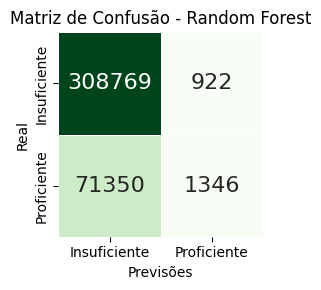

In [16]:
# Configurando os dados de entrada

df_2019['PROFICIENCIA_DESCRICAO'] = (
    df_2019['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Variáveis explicativas
X = pd.get_dummies(
    df_2019.drop(columns=['PROFICIENCIA_DESCRICAO']),
    drop_first=True
)

# Variável resposta
y = df_2019['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Remove registros inválidos
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinando o modelo Random Forest com parâmetros fixos
rf = RandomForestClassifier(
    n_estimators=200,   # Número de árvores
    max_depth=15,       # Profundidade máxima
    min_samples_split=5,  # Mínimo de amostras para divisão
    random_state=42
)
rf.fit(X_train, y_train)

# Previsões com o modelo treinado
y_pred_rf = rf.predict(X_test)

# Avaliação do modelo Random Forest
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['Insuficiente', 'Proficiente']))

# Matriz de confusão para Random Forest
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Greens", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest")
plt.tight_layout()
plt.show()


#### 2021


Classification Report - Random Forest:
              precision    recall  f1-score   support

Insuficiente       0.84      1.00      0.91    316925
 Proficiente       0.00      0.00      0.00     60311

    accuracy                           0.84    377236
   macro avg       0.42      0.50      0.46    377236
weighted avg       0.71      0.84      0.77    377236



C:\Users\emill\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emill\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emill\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

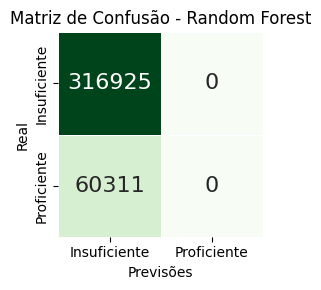

In [17]:
# Configurando os dados de entrada

df_2021['PROFICIENCIA_DESCRICAO'] = (
    df_2021['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Variáveis explicativas
X = pd.get_dummies(
    df_2021.drop(columns=['PROFICIENCIA_DESCRICAO']),
    drop_first=True
)

# Variável resposta
y = df_2021['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Remove registros inválidos
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinando o modelo Random Forest com parâmetros fixos
rf = RandomForestClassifier(
    n_estimators=200,   # Número de árvores
    max_depth=15,       # Profundidade máxima
    min_samples_split=5,  # Mínimo de amostras para divisão
    random_state=42
)
rf.fit(X_train, y_train)

# Previsões com o modelo treinado
y_pred_rf = rf.predict(X_test)

# Avaliação do modelo Random Forest
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['Insuficiente', 'Proficiente']))

# Matriz de confusão para Random Forest
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Greens", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest")
plt.tight_layout()
plt.show()


#### 2023


Classification Report - Random Forest:
              precision    recall  f1-score   support

Insuficiente       0.83      1.00      0.91    341565
 Proficiente       0.61      0.01      0.02     68967

    accuracy                           0.83    410532
   macro avg       0.72      0.50      0.46    410532
weighted avg       0.80      0.83      0.76    410532



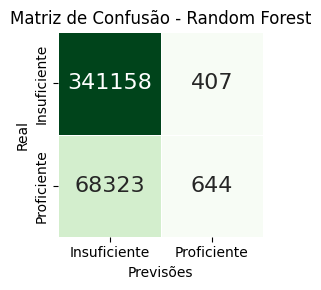

In [18]:
# Configurando os dados de entrada

df_2023['PROFICIENCIA_DESCRICAO'] = (
    df_2023['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Variáveis explicativas
X = pd.get_dummies(
    df_2023.drop(columns=['PROFICIENCIA_DESCRICAO']),
    drop_first=True
)

# Variável resposta
y = df_2023['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Remove registros inválidos
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinando o modelo Random Forest com parâmetros fixos
rf = RandomForestClassifier(
    n_estimators=200,   # Número de árvores
    max_depth=15,       # Profundidade máxima
    min_samples_split=5,  # Mínimo de amostras para divisão
    random_state=42
)
rf.fit(X_train, y_train)

# Previsões com o modelo treinado
y_pred_rf = rf.predict(X_test)

# Avaliação do modelo Random Forest
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['Insuficiente', 'Proficiente']))

# Matriz de confusão para Random Forest
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Greens", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest")
plt.tight_layout()
plt.show()
